## Exercise 4.1: Determining Assets at Risk - Weather and Climate

For this first exercise the aim is to understand the historical weather patterns in your specific area of interest. This is essential to understanding the historical exposure of particular assets as a first step as we build toward identifying which assets might be at risk in the future. 

First let's load the libraries in python for data processing and set some figure formatting.


In [77]:
import pandas as pd
import matplotlib.pyplot as plt
%pip install -q openpyxl
plt.rcParams["figure.figsize"] = (12, 6)

Note: you may need to restart the kernel to use updated packages.


c:\Users\DONALDDL\td2026\.venv\Scripts\python.exe: No module named pip


### **Data**: 
For Exercise 4.1 we will be using https://open-meteo.com to collect data for a specific latitude/longitude. For this step you can either use the latitude/longitude of Cambridge, England as an example (52.2N, 0.12E) as an example, or you can enter in the latitude and longitude of your own substation or region of interest. 
Once you have decided upon a location for the example, go to the following link: https://open-meteo.com/en/docs/historical-weather-api and enter the latitude and longitude and time zone of interest as shown in Figure 1. Also, select the time period of interest. In this case we will select data for a 30 year period from 1996-2025.

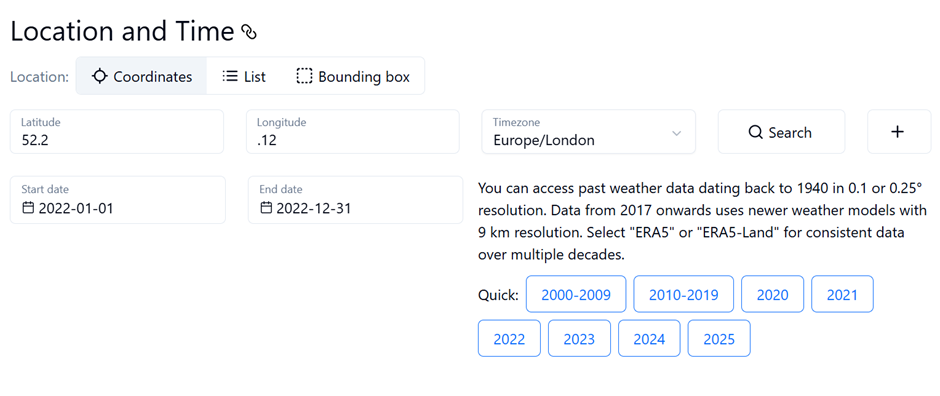

In [78]:
lat_loc = 52.2
lon_loc = 0.12
loc_name = "Cambridge"

Once you have entered in the location, you will need to select which weather/climate parameters you are interested in. In this example, we are going to use daily mean, min and max temperature, wind speed, wind gust, and total precipitation.
Once you have selected all of the weather parameters that you are interested in, you can then click download to the file format of your choice (e.g. excel). 


In [79]:
filename_weather = "open-meteo-52.20N0.17E14m.xlsx"
example_vars = [
        "temperature_2m_mean (°C)",
        "temperature_2m_max (°C)",
        "temperature_2m_min (°C)",
        "wind_speed_10m_max (km/h)",
        "wind_gusts_10m_max (km/h)",
        "precipitation_sum (mm)"
    ]

### Exploratory Data Analysis: 
With the weather data for our region of interest downloaded, we can now explore trends in the extremes experienced by a given area. For example, 30 years of daily temperature and wind gusts for Cambridge, England can be seen in Figures 4.1.2 and 4.1.3. 

Let's write a function to load the selected variables of interest.

In [80]:
def load_open_meteo_excel(path, weather_vars):
    df = pd.read_excel(path, header = 3) # The header is because the first two rows are metadata
    df = df.rename(columns={"time": "date"})
    df["date"] = pd.to_datetime(df["date"], origin="unix", unit="D", errors="coerce")
    numeric_cols = weather_vars
    df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric, errors="coerce")
    return df [["date"] + numeric_cols]

df_weather = load_open_meteo_excel(filename_weather,example_vars)

Next load the weather into a pandas dataframe.

In [81]:
df_weather = pd.read_excel(filename_weather, header = 3)
df_weather.dtypes

time                         datetime64[us]
temperature_2m_mean (°C)            float64
temperature_2m_max (°C)             float64
temperature_2m_min (°C)             float64
wind_speed_10m_max (km/h)           float64
wind_gusts_10m_max (km/h)           float64
precipitation_sum (mm)              float64
dtype: object

Let's take a look at the meteorological parameters of interest.

In [82]:
def plot_temperature_timeseries(df):
    plt.plot(df["time"], df["temperature_2m_mean (°C)"], label="Mean")
    plt.plot(df["time"], df["temperature_2m_max (°C)"], label="Max")
    plt.plot(df["time"], df["temperature_2m_min (°C)"], label="Min")
    plt.xlabel("Date Time")
    plt.ylabel("Temperature (°C)")
    plt.title("Daily Temperature Statistics")
    plt.legend()
    plt.show()
def plot_var(df,weather_var, weather_unit):
    plt.plot(df["time"], df[weather_var])
    plt.xlabel("Date Time")
    plt.ylabel(weather_unit)
    plt.show()


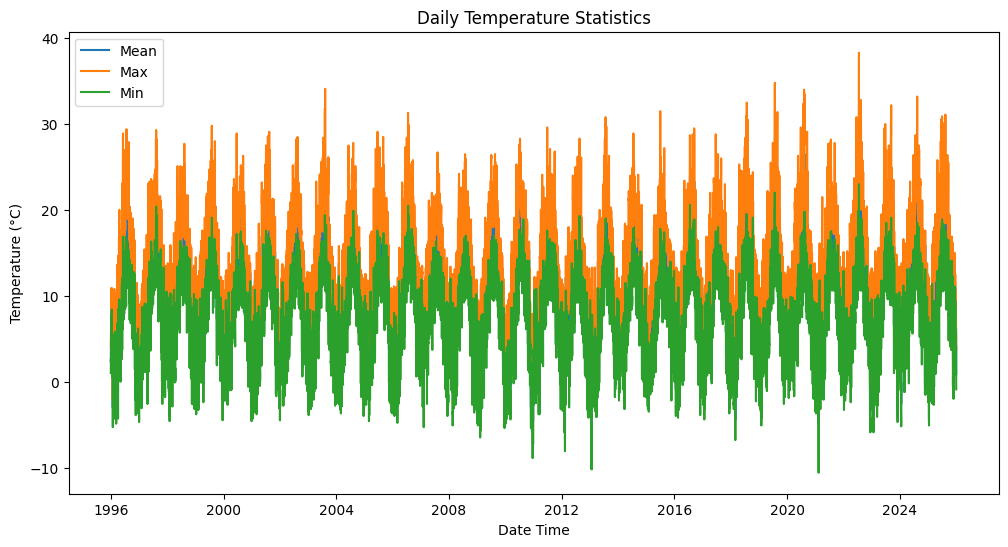

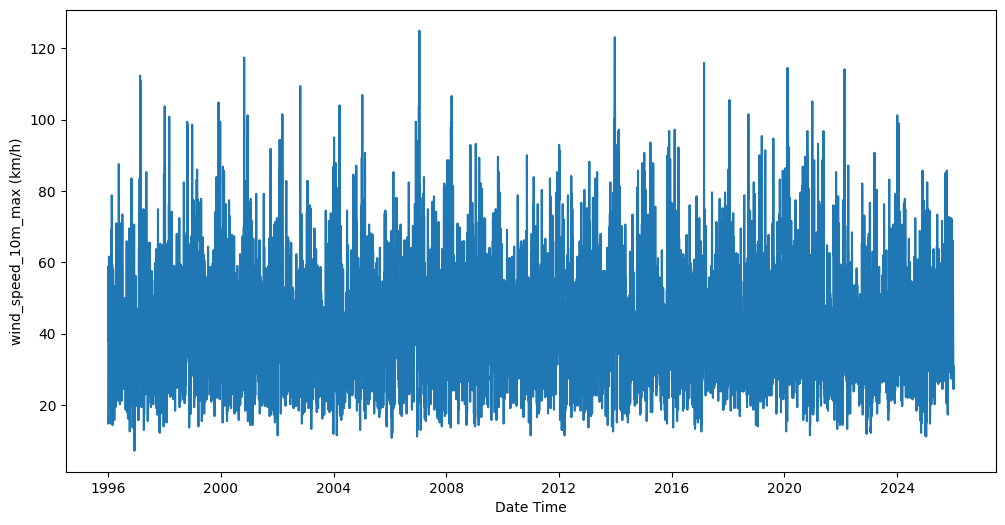

In [83]:
plot_temperature_timeseries(df_weather)
plot_var(df_weather,example_vars[4],"wind_speed_10m_max (km/h)")

Let's look at a single year: 2022

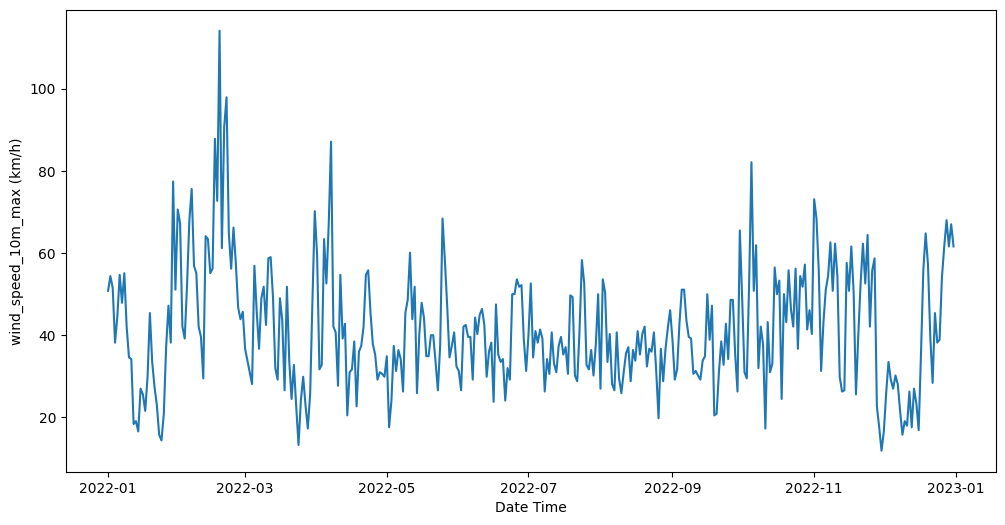

In [84]:
plot_var(df_weather[df_weather.time.dt.year==2022],example_vars[4],"wind_speed_10m_max (km/h)")

Let's take a look at the boxplots of each of these variables.

In [85]:
def boxplot_var(df, weather_var, weather_unit):
    data = [df[var].dropna() for var in weather_var]

    fig, ax = plt.subplots()
    ax.boxplot(data)

    ax.set_xticks(range(1, len(weather_var) + 1))
    ax.set_xticklabels(weather_var, rotation=45)

    ax.set_ylabel(weather_unit)
    ax.set_xlabel("Weather Variable")

    plt.tight_layout()
    plt.show()


Although you wouldn't do this in practice, a boxplot of all of the variables on a common axis lets you see the spread of each.

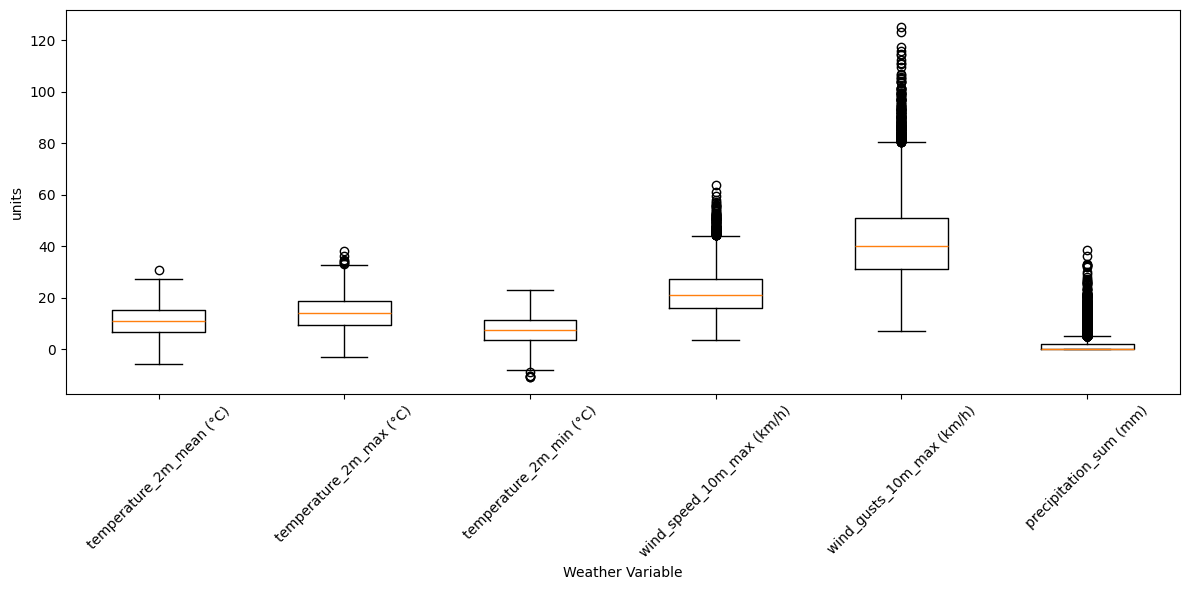

In [86]:
boxplot_var(df_weather,example_vars[0:6],"units")

### Activity:
Now that you have seen the distribution and values for Cambridge, try to follow the workflow yourself for your own region of interest and answer the exercise questions below.
 
#### Q4.1.1. How does the historical weather for your area of interest compare to that of the example? 
#### Q4.1.2. What are the implications of your findings for resilience and design of electricity distribution networks?
#### Q4.1.3. Open-meteo provides access to future climate models as well as historical weather. Selecting one of the future models, explore how the temperature is projected to change in your area of interest.


**BONUS** For those of you who are more experienced python users, UKPN has released a package (ukpyn) which allows you to get a list of all of the primary substation locations. Using their API can you extract the substation locations and then find out which primaries are exposed to the most extreme values of each of the meteorological variables in 2022?

See the package here for a guide to getting started with the weather data: https://github.com/UKPN-DSO/ukpyn/blob/main/examples/weatherdata.ipynb